In [202]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.style.use("seaborn-v0_8")

coin = pd.read_csv(
    "/Users/lizeyu/Desktop/Quant-on-Crypto/strategies/mmpair-strategy/mmpair-strategy/1m_klines_raw/DOGEUSDT_klines_1m.csv"
)

# 时间戳统一到微秒
coin["Close Time"] = coin["Close Time"].apply(
    lambda x: x * 1000 + 999 if x < 2000000000000 else x
)
coin["Open Time"] = coin["Open Time"].apply(
    lambda x: x * 1000 if x < 2000000000000 else x
)

# 将时间戳转换为 datetime 格式
coin["Close Time"] = pd.to_datetime(coin["Close Time"], unit="us")
coin["Open Time"] = pd.to_datetime(coin["Open Time"], unit="us")

# 设置索引
coin.set_index("Close Time", inplace=True)
coin.sort_index(inplace=True)

In [203]:
# coin = coin.loc[:'2025-01-01']
# coin = coin.loc['2024-06-01':'2025-06-01']
# coin = coin.loc['2025-03-01':]#'2025-06-01']
coin = coin.loc['2025-06-01':]



In [204]:
close_prices = coin["Close"].astype(float)

In [205]:
window_ma = 24*60
window_fft = 5*24*60

In [206]:
close_prices_ma = close_prices.rolling(window=window_ma).mean()
close_prices_residual = close_prices - close_prices_ma

In [207]:
mae = []

In [208]:
best_periods = []
times = []

for idx, i in enumerate(tqdm(range(window_fft, len(close_prices_residual), 60 ), desc="Processing FFT")):
    close_prices_roll = close_prices_residual[i-window_fft:i]
    time = close_prices_roll.index

    # plt.figure(figsize=(12, 6))
    # plt.plot(close_prices_roll.index, close_prices_roll.values, label="Close Price")
    # plt.title("DOGEUSDT Close Prices")
    # plt.xlabel("Time")
    # plt.ylabel("Price (USDT)")
    # plt.legend()

    # ---------- Step1: 输入数据 ----------
    price = close_prices_roll
    t = np.arange(len(price))

    # 实际使用可改为：
    # df = pd.read_csv("price.csv")
    # price = df['close'].values
    # t = np.arange(len(price))


    # ---------- Step2: FFT 傅里叶变换 ----------
    fft_coeff = np.fft.fft(price)
    freq = np.fft.fftfreq(len(price))
    power = np.abs(fft_coeff)



    idx_max = np.argsort(power)[-1]  # 最大能量的频率下标
    idx_max_2 = np.argsort(power)[-2]  # 最大能量的频率下标
    idx_max_3 = np.argsort(power)[-3]  # 最大能量的频率下标
    idx_max_4 = np.argsort(power)[-4]  # 最大能量的频率下标
    idx_max_5 = np.argsort(power)[-5]  # 最大能量的频率下标
    per = []
    for idx in [idx_max, idx_max_2, idx_max_3, idx_max_4, idx_max_5]:
        freq_val = abs(freq[idx])
        if freq_val != 0:
            period = 1 / freq_val
            per.append(period)

    per = np.array(per)

    
    best_periods.append(per[0])
    times.append(time[-1])

    # # ---------- Step3: 获取最主要频率 ----------
    # k = 10  # 输出前10个最强成分
    # idx = np.argsort(power)[-k:]  # 最大能量的频率下标
    # # 打印主要频率成分信息
    # components = []
    # print("\nTop Fourier Components:")
    # print("Rank | Frequency | Amplitude | Phase(rad)")

    # for rank,i in enumerate(idx[::-1],1):   # 从最大开始打印
    #     amplitude = np.abs(fft_coeff[i])/len(price)*2  # 还原幅值(对称性*2)
    #     phase = np.angle(fft_coeff[i])
    #     freq_val = abs(freq[i])

    #     components.append((freq_val, amplitude, phase))

    #     print(f"{rank:4d} | {freq_val:.6f} | {amplitude:.4f} | {phase:.4f}")


    # # ---------- Step4: 重构信号 ----------
    # fft_filtered = np.zeros_like(fft_coeff)
    # fft_filtered[idx] = fft_coeff[idx]
    # price_reconstructed = np.fft.ifft(fft_filtered).real


    # # ---------- Step5: 可视化 ----------
    # plt.figure(figsize=(12,6))
    # plt.plot(t, price, label='Original Price')
    # plt.plot(t, price_reconstructed, label='Reconstructed (Top k Frequencies)', linewidth=2)
    # plt.legend()
    # plt.title("Financial Timeseries FFT Reconstruction")
    # plt.xlabel("Time")
    # plt.ylabel("Value")
    # plt.show()

    # # 频谱图
    # plt.figure(figsize=(10,4))
    # plt.stem(freq[:30*k], power[:30*k])
    # plt.title("Frequency Domain Spectrum")
    # plt.xlabel("Frequency")
    # plt.ylabel("Magnitude")
    # plt.show()


Processing FFT:   0%|          | 0/3552 [00:00<?, ?it/s]

Processing FFT: 100%|██████████| 3552/3552 [00:07<00:00, 497.49it/s]


In [209]:
pd.Series(best_periods).describe()

count    3552.000000
mean     5506.732625
std      2022.335273
min      1028.571429
25%      3600.000000
50%      7200.000000
75%      7200.000000
max      7200.000000
dtype: float64

In [210]:
period_list = pd.Series(best_periods).unique()

In [211]:
len(period_list)

6

In [212]:
import pandas as pd
best_periods_with_time = pd.Series(best_periods, index=times).to_frame(name='Best Period')
# 若 Time 是 index，先 reset_index
best_df = best_periods_with_time.reset_index().rename(columns={'index':'Time'})
best_df['Time'] = pd.to_datetime(best_df['Time'])

coin.reset_index(inplace=True)

coin = pd.merge_asof(
    coin.sort_values('Close Time'),
    best_df.sort_values('Time'),
    left_on='Close Time',
    right_on='Time',
    direction='backward'    # 使用前值
)

coin.rename(columns={'Best Period':'best_period'}, inplace=True)


In [213]:


# # ---------- 输出频率成分信息 ----------
# print("\nTop Fourier Components with Period:")
# print("Rank | Frequency | Period | Amplitude | Phase")

# components = []
# for rank,i in enumerate(idx[::-1],1):
#     A = np.abs(fft_coeff[i]) / len(price) * 2
#     phi = np.angle(fft_coeff[i])
#     f = abs(freq[i])
#     period = (1/f) if f != 0 else np.inf

#     components.append((i,f,period,A,phi))
#     print(f"{rank:4d} | {f:.6f} | {period:8.2f} | {A:9.5f} | {phi:9.3f}")
# # ========= Step4 正负频率合成可视化 =========

# fig, axes = plt.subplots(len(components)+1, 1, figsize=(12, 2.5*(k+1)), sharex=True)

# axes[0].plot(t, price, color='black', linewidth=1.3)
# axes[0].set_title("Original Financial Time Series")
# axes[0].grid(True)

# wave_sum = np.zeros_like(price)

# for ax, (i,f,period,A,phi) in zip(axes[1:], components):

#     # ---------- 0频直流项 ----------
#     if f == 0:
#         comp = np.ones_like(t) * (fft_coeff[i].real/len(price))

#     # ---------- 正负频率合成交 cos 波 ----------
#     else:
#         # 找到对应负频率索引（DFT 共轭对称）
#         j = np.where(freq == -f)[0][0]
#         X = fft_coeff[i] + np.conj(fft_coeff[j])   # 正负频合并
#         A = np.abs(X) / len(price)                 # 真实幅度
#         phi = np.angle(X)                          # 正确相位（已为弧度，无需转换）
#         comp = A * np.cos(2*np.pi*f*t + phi)

#     wave_sum += comp

#     # ---------- 画图 ----------
#     ax.plot(t, price, color="grey", alpha=0.45, label="Original Reference")
#     ax.plot(t, comp, color='blue', linewidth=1.4,
#             label=f"f={f:.4f}  Period={period:.1f}  A={A:.5f}")
#     ax.legend()
#     ax.grid(True)

# plt.tight_layout()
# plt.show()


# # ---------- Step5 主成分重建 vs 原序列 ----------
# plt.figure(figsize=(12,5))
# plt.plot(t, price,label="Original",linewidth=1.5)
# plt.plot(t, wave_sum,label="Reconstructed (Top Frequencies)",linewidth=2)
# plt.title("Original vs Fourier Reconstruction (Using Top Components)")
# plt.legend()
# plt.show()


In [214]:
# # 检查保留前K个频率的手动重建 vs numpy ifft裁剪重建
# re_fft = np.zeros_like(fft_coeff, dtype=complex)
# re_fft[idx[-k:]] = fft_coeff[idx[-k:]]  # 保留TopK的频域能量
# manual_recon = wave_sum
# ifft_recon = np.fft.ifft(re_fft).real

# plt.figure(figsize=(12,5))
# plt.plot(t, price,label="Original")
# plt.plot(t, manual_recon,label="Manual Cosine Reconstruction")
# plt.plot(t, ifft_recon,label="IFFT using only TopK frequencies",linestyle='--')
# plt.legend()
# plt.title("Manual vs IFFT Limited Frequency Reconstruction")
# plt.show()


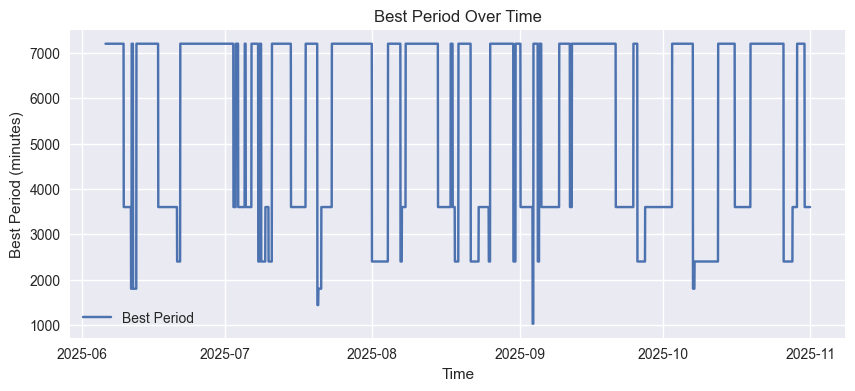

In [215]:
plt.figure(figsize=(10, 4))
plt.plot(best_df['Time'], best_df['Best Period'], label='Best Period')
plt.title("Best Period Over Time")
plt.xlabel("Time")
plt.ylabel("Best Period (minutes)")
plt.legend()
plt.show()

In [216]:
per

array([3600., 3600., 7200., 7200.])

In [217]:
period_map = {period: i for i, period in enumerate(period_list)}

for i, period in enumerate(period_list):
    deri_window = 1  # 2d
    n = int(period/4)  # VWAP window in 5m
    # threshold = 750    # $/d

    cum_vol = coin["Volume"].rolling(window=n).sum()
    cum_vol_px = (coin["Close"] * coin["Volume"]).rolling(window=n).sum()
    coin[f"VWAP_{i}"] = cum_vol_px / cum_vol

    cum_vol = coin["Volume"].rolling(window=n).sum()
    cum_vol_px = (coin["Close"] * coin["Volume"]).rolling(window=n).sum()
    coin[f"VWAP_{i}"] = cum_vol_px / cum_vol
    shift_steps = n
    coin[f"VWAP_derivative_{i}"] = (coin[f"VWAP_{i}"] - coin[f"VWAP_{i}"].shift(shift_steps)) / deri_window
    coin[f"VWAP_derivative2_{i}"] = (
        coin[f"VWAP_derivative_{i}"] - coin[f"VWAP_derivative_{i}"].shift(shift_steps)
    ) / deri_window
    coin[f"VWAP_derivative3_{i}"] = (
        coin[f"VWAP_derivative2_{i}"] - coin[f"VWAP_derivative2_{i}"].shift(shift_steps)
    ) / deri_window

    coin[f"pos_{i}"] = (
    (coin[f"VWAP_derivative_{i}"] > 0)
    # & (coin[f"VWAP_derivative2_{i}"] > 0)
    # & (coin["VWAP_derivative3"] > 0)
    )
    coin[f"neg_{i}"] = (
    (coin[f"VWAP_derivative_{i}"] < 0)
    # & (coin[f"VWAP_derivative2_{i}"] < 0)
    # & (coin["VWAP_derivative3"] < 0)
)

In [218]:
# deri_window = 1  # 2d
n = int(900)  # VWAP window in 5m
# threshold = 750    # $/d
# 
cum_vol = coin["Volume"].rolling(window=n).sum()
cum_vol_px = (coin["Close"] * coin["Volume"]).rolling(window=n).sum()
coin["VWAP"] = cum_vol_px / cum_vol

cum_vol = coin["Volume"].rolling(window=n).sum()
cum_vol_px = (coin["Close"] * coin["Volume"]).rolling(window=n).sum()
coin["VWAP"] = cum_vol_px / cum_vol
shift_steps = n
coin["VWAP_derivative"] = (coin["VWAP"] - coin["VWAP"].shift(shift_steps)) / deri_window
coin["VWAP_derivative2"] = (
    coin["VWAP_derivative"] - coin["VWAP_derivative"].shift(shift_steps)
) / deri_window
coin["VWAP_derivative3"] = (
    coin["VWAP_derivative2"] - coin["VWAP_derivative2"].shift(shift_steps)
) / deri_window

coin["pos"] = (
    (coin["VWAP_derivative"] > 0)
    # & (coin["VWAP_derivative2"] > 0)
    # & (coin["VWAP_derivative3"] > 0)
)
coin["neg"] = (
    (coin["VWAP_derivative"] < 0)
    # & (coin["VWAP_derivative2"] < 0)
    # & (coin["VWAP_derivative3"] < 0)
)

In [219]:
# 在所有子图上绘制贯穿的竖线并在正区域上色


In [220]:
# 在 VWAP_derivative 和 VWAP_derivative2 都小于0的区域上色


In [221]:
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# # Plot Close and VWAP on the first subplot
# ax1.plot(coin["Close"], label="Close", alpha=0.6)
# ax1.plot(coin["VWAP"], label="VWAP", color="blue")
# ax1.set_ylabel("Price")
# ax1.set_title("VWAP and VWAP_derivative")
# ax1.legend(loc="upper left")

# # Plot VWAP_derivative on the second subplot
# ax2.plot(coin["VWAP_derivative"], label="VWAP_derivative", color="orange")
# ax2.set_ylabel("VWAP_derivative")
# ax2.legend(loc="upper left")

# # Plot VWAP_derivative2 on the third subplot
# ax3.plot(coin["VWAP_derivative2"], label="VWAP_derivative2", color="red")
# ax3.set_ylabel("VWAP_derivative2")
# ax3.legend(loc="upper left")

# # Set the x-axis label for the bottom subplot
# ax3.set_xlabel("Time")

# # 在 ax2 和 ax3 上绘制 y=0 的横线
# ax2.axhline(0, color='gray', linestyle='--', linewidth=1, label='y=0')
# ax3.axhline(0, color='gray', linestyle='--', linewidth=1, label='y=0')

# # 找到 VWAP_derivative 和 VWAP_derivative2 与 y=0 的交点
# cross_points_derivative = coin[coin["VWAP_derivative"] * coin["VWAP_derivative"].shift(1) < 0]
# cross_points_derivative2 = coin[coin["VWAP_derivative2"] * coin["VWAP_derivative2"].shift(1) < 0]


# for cross_time in cross_points_derivative.index:
#   ax1.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax2.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax3.axvline(cross_time, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)

# for cross_time in cross_points_derivative2.index:
#   ax1.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax2.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
#   ax3.axvline(cross_time, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

# # 在 VWAP_derivative 和 VWAP_derivative2 都大于0的区域上色
# positive_region = (coin["VWAP_derivative"] > 0) & (coin["VWAP_derivative2"] > 0)
# for start, end in zip(positive_region[positive_region].index[:-1], positive_region[positive_region].index[1:]):
#   if (end - start).total_seconds() / 60 == 5:  # 确保连续区域
#     ax1.axvspan(start, end, color='yellow', alpha=0.2)
#     ax2.axvspan(start, end, color='yellow', alpha=0.2)
#     ax3.axvspan(start, end, color='yellow', alpha=0.2)

# positive_region = (coin["VWAP_derivative"] < 0) & (coin["VWAP_derivative2"] < 0)
# for start, end in zip(positive_region[positive_region].index[:-1], positive_region[positive_region].index[1:]):
#   if (end - start).total_seconds() / 60 == 5:  # 确保连续区域
#     ax1.axvspan(start, end, color='blue', alpha=0.03)
#     ax2.axvspan(start, end, color='blue', alpha=0.03)
#     ax3.axvspan(start, end, color='blue', alpha=0.03)
# # 显示更新后的图形
# fig.canvas.draw()

# plt.tight_layout()
# plt.show()

In [222]:
# import matplotlib.pyplot as plt
# import pandas as pd

# # ===== 假设 coin 是你的原始 DataFrame =====
# # 这里示例直接用 coin 中的 VWAP_derivative 和 VWAP_derivative2

# # 1️⃣ 定义黄色与蓝色区域的布尔掩码
# mask_yellow = (coin["VWAP_derivative"] > 0) & (
#     coin["VWAP_derivative2"] > 0 & (coin["VWAP_derivative3"] > 0)
# )
# mask_blue = (coin["VWAP_derivative"] < 0) & (
#     coin["VWAP_derivative2"] < 0 & (coin["VWAP_derivative3"] < 0)
# )

# # 2️⃣ 生成两条曲线（不满足条件的地方用 NaN 保持时间轴一致）
# yellow_curve = np.where(mask_yellow, coin["Close"], np.nan)
# blue_curve = np.where(mask_blue, coin["Close"], np.nan)

# # 3️⃣ 新 figure 绘图
# fig2, ax = plt.subplots(figsize=(12, 5))
# ax.plot(coin.index, yellow_curve, color="gold", lw=2, label="Positive Region (Yellow)")
# ax.plot(coin.index, blue_curve, color="dodgerblue", lw=2, label="Negative Region (Blue)")
# ax.set_title("Extracted Region Curves")
# ax.set_ylabel("Close Price")
# ax.set_xlabel("Time")
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [223]:
coin.set_index("Close Time", inplace=True)

In [224]:
coin = coin[coin['best_period'].notnull()]

Processing: 100%|██████████| 213121/213121 [00:02<00:00, 71520.13it/s]


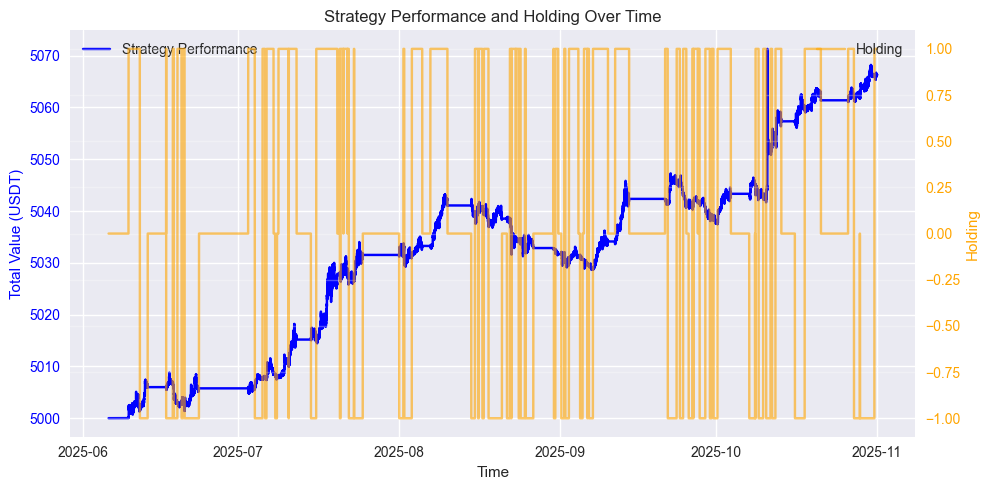

In [225]:
from collections import deque

import numpy as np
import pandas as pd
from tqdm import tqdm


def implement_strategy(
    coin: pd.DataFrame,
    trade_size: float,
    initial_cap: float = 5000.0,
    fee: float = 0.0005,
):
    prices = coin["Close"].values
    n = len(prices)



    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap  # USDT
    amount = 0.0  # 持仓coin数量
    open_orders = deque()  # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    mae_temp = 0.0

    for t in tqdm(range(n), desc="Processing"):
        if now_holding == 0:
            period = coin['best_period'].iloc[t].item()     
            # print(period)
            iperiod = period_map[period]
        
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        # if t >= 1 and coin[f"pos"].iloc[t - 1] and now_holding == 0  and period<4000:
        if t >= 1 and coin[f"pos_{iperiod}"].iloc[t - 1] and now_holding == 0  and period<4000:
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # --- 卖空信号 ---
        if (
            # t >= 1 and coin[f'neg'].iloc[t-1]
            t >= 1 and coin[f'neg_{iperiod}'].iloc[t-1]
            and now_holding==0  and period<4000 #and period>3000
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital += trade_size-trade_size * fee
                amount -= qty
                now_holding -= 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})

        # if not coin[f"pos"].iloc[t] and now_holding > 0:
        if not coin[f"pos_{iperiod}"].iloc[t] and now_holding > 0:
            # 平多仓
            while open_orders and now_holding > 0:
                order = open_orders.popleft()
                sell_qty = order["qty"]
                sell_price = price_t
                proceeds = sell_qty * sell_price * (1 - fee)
                capital += proceeds
                amount -= sell_qty
                now_holding -= 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (sell_price - entry_price) / entry_price
                pnl_records[t] += pnl
        # if not coin[f'neg'].iloc[t] and now_holding < 0:
        if not coin[f'neg_{iperiod}'].iloc[t] and now_holding < 0:
            # 平空仓
            while open_orders and now_holding < 0:
                order = open_orders.popleft()
                buy_qty = order["qty"]
                buy_price = price_t
                cost = buy_qty * buy_price * (1 + fee)
                capital -= cost
                amount += buy_qty
                now_holding += 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (entry_price - buy_price) / entry_price
                pnl_records[t] += pnl

    # 生成结果
    performance_df = pd.DataFrame({"Total Value": total_value}, index=coin.index)
    holding_series = pd.Series(holdings_array, index=coin.index)
    pnl_series = pd.Series(pnl_records, index=coin.index)
    return performance_df, pnl_series, holding_series

# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(coin, trade_size=50.0, initial_cap=5000.0)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()


x = [i * 5 for i in range(len(strategy_performance))]  # 每一行对应的分钟数


# 策略表现
ax1.plot(
    strategy_performance.index,
    strategy_performance["Total Value"],
    label="Strategy Performance",
    color="blue",
)
ax1.set_ylabel("Total Value (USDT)", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# 持仓
ax2.plot(
    strategy_performance.index,
    holding.values,
    label="Holding",
    color="orange",
    alpha=0.6,
)
ax2.set_ylabel("Holding", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

plt.title("Strategy Performance and Holding Over Time")
ax1.set_xlabel("Time")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [226]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# Filter pnls and maes to the common time axis


pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0])
    / abs(np.mean(pnls_array[pnls_array < 0]))
    if np.any(pnls_array < 0)
    else float("inf"),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array)
    if np.std(pnls_array) > 0
    else 0,
    "总收益率": np.sum(pnls_array),
}

# 打印统计指标
for key, value in stats.items():
    print(
        f"{key}: {value:.4f}"
        if isinstance(value, (float, np.float64))
        else f"{key}: {value}"
    )

总交易次数: 97
平均收益率: 0.0146
中位数收益率: -0.0002
最大收益率: 0.2556
最小收益率: -0.0779
标准差: 0.0529
正收益交易数: 46
负收益交易数: 51
胜率: 0.4742
盈亏比: 2.9422
夏普比率: 0.2761
总收益率: 1.4171


In [227]:
strategy_performance.to_csv("strategy_performance_DOGE_test.csv")